# Breast Cancer Classification Assignment

### 1. Load the dataset using pandas

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression


# group 11
# Jonathan Elahee
# Jennifer Lim
# Palwinder Singh



# URL for the Breast Cancer Wisconsin (Diagnostic) dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/breast-cancer-wisconsin/wdbc.data"

# Column names based on dataset description
column_names = ['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 
                'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave_points_mean', 
                'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 
                'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave_points_se', 
                'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 
                'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 
                'concavity_worst', 'concave_points_worst', 'symmetry_worst', 'fractal_dimension_worst']

df = pd.read_csv(url, names=column_names)

# Map diagnosis to binary values: Malignant (1), Benign (0)
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,842302,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


### 2. Summarize the dataset

In [2]:
print("Dataset Summary:")
print(df.describe())
print("\nClass Distribution (1=M, 0=B):")
print(df['diagnosis'].value_counts())

Dataset Summary:
                 id   diagnosis  radius_mean  texture_mean  perimeter_mean  \
count  5.690000e+02  569.000000   569.000000    569.000000      569.000000   
mean   3.037183e+07    0.372583    14.127292     19.289649       91.969033   
std    1.250206e+08    0.483918     3.524049      4.301036       24.298981   
min    8.670000e+03    0.000000     6.981000      9.710000       43.790000   
25%    8.692180e+05    0.000000    11.700000     16.170000       75.170000   
50%    9.060240e+05    0.000000    13.370000     18.840000       86.240000   
75%    8.813129e+06    1.000000    15.780000     21.800000      104.100000   
max    9.113205e+08    1.000000    28.110000     39.280000      188.500000   

         area_mean  smoothness_mean  compactness_mean  concavity_mean  \
count   569.000000       569.000000        569.000000      569.000000   
mean    654.889104         0.096360          0.104341        0.088799   
std     351.914129         0.014064          0.052813        

### 3. Check for missing values and handle them

In [3]:
print("Missing Values:")
print(df.isnull().sum())
# The WDBC dataset usually has no missing values, but if it did, we would use:
# df.fillna(df.mean(), inplace=True)

Missing Values:
id                         0
diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave_points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave_points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave_points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64


### 4. Perform feature scaling

In [4]:
X = df.drop(columns=['id', 'diagnosis'])
y = df['diagnosis']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

### 5. Histogram plots for 4 features

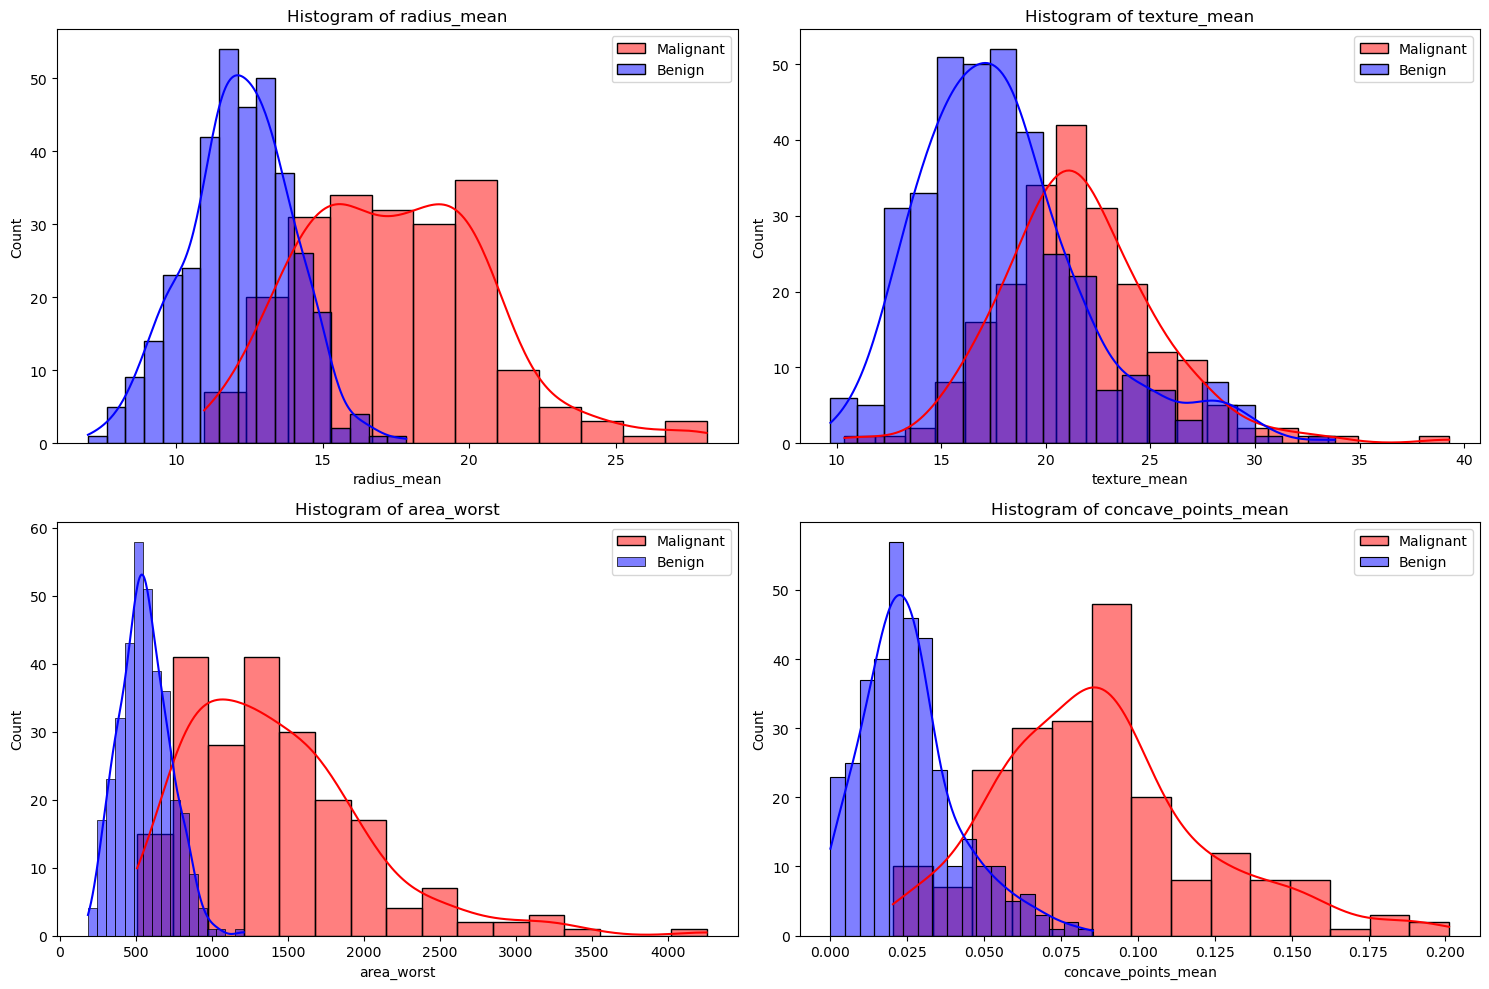

In [5]:
features_to_plot = ['radius_mean', 'texture_mean', 'area_worst', 'concave_points_mean']

plt.figure(figsize=(15, 10))
for i, feature in enumerate(features_to_plot):
    plt.subplot(2, 2, i+1)
    sns.histplot(df[df['diagnosis'] == 1][feature], color='red', label='Malignant', kde=True)
    sns.histplot(df[df['diagnosis'] == 0][feature], color='blue', label='Benign', kde=True)
    plt.title(f'Histogram of {feature}')
    plt.legend()
plt.tight_layout()
plt.show()

**Observations from histograms:**
1. **radius_mean**: Malignant tumors generally have larger mean radius values than the benign, but there is a large range of overlap.
2. **texture_mean**: Much overlap but malignant tumors tend to have higher texture mean.
3. **area_worst**: This feature exhibits significant separation between the two classes and higher area values of this feature is an indicative of a malignant tumors.
4. **concave_points_mean**: There is a clear separation where malignant samples have invariably higher concave points mean values; it could be a very good predictor.

### 6, 7, 8. Split data, train Logistic Regression, make predictions on test set

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1] # Probability for class 1

### 9. Custom Metric Functions

In [7]:
def custom_accuracy(y_true, y_pred):
    correct = np.sum(y_true == y_pred)
    return correct / len(y_true)

def custom_log_likelihood(y_true, y_prob):
    # L = sum(y*log(p) + (1-y)*log(1-p))
    epsilon = 1e-15 # To avoid log(0)
    y_prob = np.clip(y_prob, epsilon, 1 - epsilon)
    return np.sum(y_true * np.log(y_prob) + (1 - y_true) * np.log(1 - y_prob))

def custom_binary_cross_entropy(y_true, y_prob):
    # BCE = -(1/n) * Log Likelihood
    ll = custom_log_likelihood(y_true, y_prob)
    return -ll / len(y_true)

acc = custom_accuracy(y_test, y_pred)
ll = custom_log_likelihood(y_test, y_prob)
bce = custom_binary_cross_entropy(y_test, y_prob)

print(f"Custom Accuracy: {acc:.4f}")
print(f"Custom Log Likelihood: {ll:.4f}")
print(f"Custom Binary Cross Entropy: {bce:.4f}")

Custom Accuracy: 0.9737
Custom Log Likelihood: -6.8422
Custom Binary Cross Entropy: 0.0600
